比较Sofa(LiverSim.py)和PD(PDStrain3DVali.py)方法变形模拟的结果差异

固定三个点[3, 39, 64]，对另一个点[85]施加指定位移[0.005, 0.0, 0.0]$\times$ 0.01 $\times$ 500

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from matplotlib.gridspec import GridSpec

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [2]:
sofa_node_pos = np.loadtxt('node_end_pos.csv', delimiter=',')
pd_node_pos = np.loadtxt('pos_before.csv', delimiter=',')

error = []
nmse = []

for i in range(len(sofa_node_pos)):
    error.append(np.linalg.norm(sofa_node_pos[i] - pd_node_pos[i]))
    nmse.append(np.sqrt(np.sum((sofa_node_pos[i] - pd_node_pos[i])**2) / np.sum(sofa_node_pos[i]**2 + pd_node_pos[i]**2)))

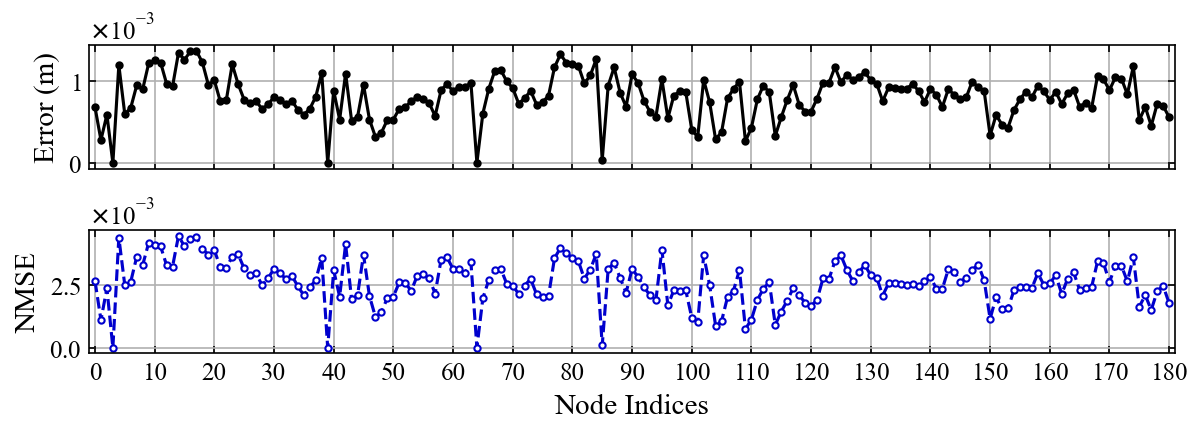

In [12]:
fig = plt.figure(figsize=(15, 6), dpi=100)
gs = GridSpec(2, 1, figure=fig)

fig.suptitle('Comparison Between SOFA Software and PD Alogirthm', fontsize=18)

# ax_move = fig.add_subplot(gs[0])
# ax_move.bar(range(len(sofa_node_pos)), np.linalg.norm(sofa_node_pos), color='r', label='SOFA')
# ax_move.bar(range(len(pd_node_pos)), np.linalg.norm(pd_node_pos), color='k', label='PD')
# ax_move.set_xlim([-1, len(sofa_node_pos)])

ax_compare = fig.add_subplot(gs[0])
ax_compare.plot(error, c='k', lw=1.5, label='Error')
# ax_compare.bar(range(len(error)), error, color='k', label='Error', zorder=3)
# ax_compare.set_title('Error between SOFA and PD', fontsize=16)
ax_compare.set_xlim([-1, len(error)])
ax_compare.set_xlabel('Node Indices', fontsize=14)
ax_compare.set_ylabel('Error (m)', fontsize=14)

ax_nmse = fig.add_subplot(gs[1])
ax_nmse.plot(nmse, c='k', lw=1.5, label='NMSE')
# ax_nmse.bar(range(len(nmse)), nmse, color='k', label='NMSE', zorder=3)
ax_nmse.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
ax_nmse.set_ylabel('NMSE', fontsize=14, fontname='Times New Roman')
ax_nmse.set_xlim([-1, len(nmse)])

# axs = [ax_move, ax_compare]
axs = [ax_compare, ax_nmse]
for ax in axs:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.offsetText.set_fontsize(12)
    ax.yaxis.get_offset_text().set_fontsize(12)
    ax.grid('True', zorder=-1)
    ax.label_outer()

---
用于论文绘图

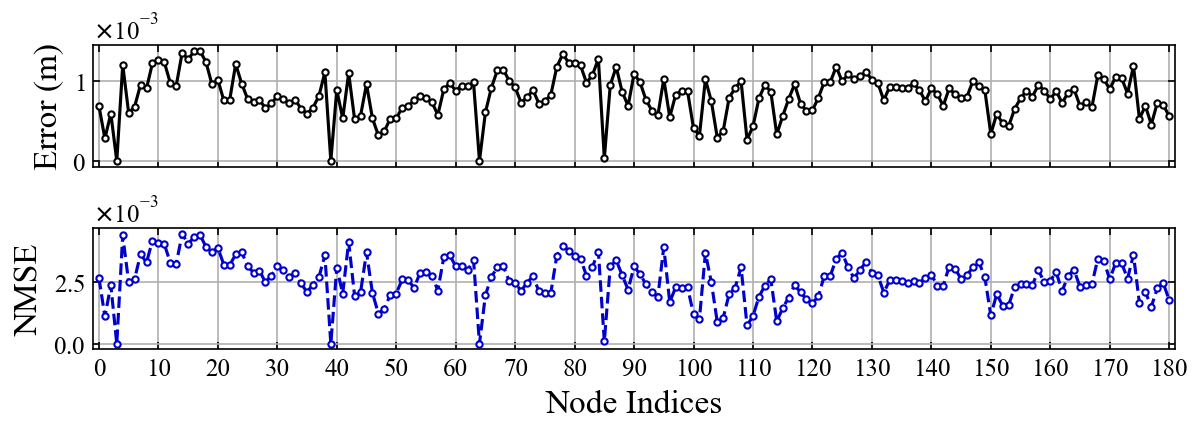

In [4]:
fig = plt.figure(figsize=(8, 3), dpi=150)
gs = GridSpec(2, 1, figure=fig)

# fig.suptitle('Comparison Between SOFA Software and PD Alogirthm', fontsize=18)

ax_compare = fig.add_subplot(gs[0])
ax_compare.plot(error, marker='.', markerfacecolor='white', c='k', lw=1.5, label='Error')
# ax_compare.bar(range(len(error)), error, color='k', label='Error', zorder=3)
# ax_compare.set_title('Error between SOFA and PD', fontsize=16)
ax_compare.set_xlim([-1, len(error)])
ax_compare.set_xlabel('Node Indices', fontsize=16)
ax_compare.set_ylabel('Error (m)', fontsize=16)

ax_nmse = fig.add_subplot(gs[1])
ax_nmse.plot(nmse, marker='.', markerfacecolor='white', linestyle='--', c='mediumblue', lw=1.5, label='NMSE')
# ax_nmse.bar(range(len(nmse)), nmse, color='k', label='NMSE', zorder=3)
ax_nmse.set_xlabel('Node Indices', fontsize=16, fontname='Times New Roman')
ax_nmse.set_ylabel('NMSE', fontsize=16, fontname='Times New Roman')
ax_nmse.set_xlim([-1, len(nmse)])

# axs = [ax_move, ax_compare]
axs = [ax_compare, ax_nmse]
for ax in axs:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    ax.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.offsetText.set_fontsize(12)
    ax.yaxis.get_offset_text().set_fontsize(12)
    ax.grid('True', zorder=-1)
    ax.label_outer()

plt.tight_layout()
fig.savefig('pd-sofa-compare.svg', transparent=True, dpi=300, bbox_inches='tight')